#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimientos**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre:** Jareth Israel Rivera Pineda

* **matrícula:** A01411621

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en Canvas:

*   **data_amazon.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **data_imdb.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **data_yelp.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.




In [36]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##**Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**

Un falso positivo en este problema ocurre cuando el modelo clasifica un comentario negativo como positivo. Por ejemplo, una reseña donde un usuario tuvo una mala experiencia podría interpretarse incorrectamente como una opinión favorable.

Un falso negativo ocurre cuando un comentario positivo es clasificado como negativo. En este caso, una buena reseña podría ser tomada como una experiencia mala.

Ambos errores tienen implicaciones importantes. Los falsos positivos podrían hacer que una empresa piense que sus productos o servicios están funcionando bien cuando en realidad existen problemas reales que los clientes están reportando. Por otro lado, los falsos negativos podrían provocar que se ignoren comentarios positivos o que se subestime la satisfacción de los clientes.

Considero que en este contexto los falsos positivos pueden ser un poco más graves, ya que interpretar opiniones negativas como positivas puede impedir detectar problemas importantes en productos o servicios y afectar la toma de decisiones.


##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [38]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [39]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

###**Cargamos los datos del problema:**

In [40]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv('/content/drive/MyDrive/MNA/TC6050.10/data_amazon.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('/content/drive/MyDrive/MNA/TC6050.10/data_imdb.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('/content/drive/MyDrive/MNA/TC6050.10/data_yelp.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (1000, 2)
Total de registros de Yelp: (1000, 2)


In [41]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # Por ejemplo, mostremos a continuación los primeros comentarios
               # y etiquetas del archivo de Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [42]:
# Y concatenamos los comentarios de los tres archivos
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfi, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [43]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

,count
label,
0,1500
1,1500


In [44]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 2:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [45]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10   
label            1
Name: 1125, dtype: object
review    10/10   
label            1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 2:**

Considero que estos dos registros no deberían descartarse, ya que aunque no contienen caracteres alfabéticos, sí expresan claramente una opinión positiva. La expresión “10/10” representa una evaluación máxima y tiene mucho significado dentro del contexto de análisis de sentimientos.

Sin embargo, después del proceso de limpieza estos comentarios quedarían vacíos si solamente se conservan caracteres alfabéticos. Por ello, una buena opción sería reemplazarlos manualmente por una palabra o expresión equivalente como “excellent”, “perfect” o “positive review”, de forma que el modelo pueda seguir interpretando correctamente el sentimiento del comentario.

Dejar las celdas vacías podría provocar pérdida de información útil, mientras que eliminarlas reduciría innecesariamente el conjunto de datos.

##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [46]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

##**Pregunta - 3:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [47]:
def clean_tok(doc):
  ##############################################################################
  # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 3:

  # Convertir a minúsculas
  doc = doc.lower()

  # Caso especial para comentarios como "10/10"
  if doc.strip() == '10/10':
    doc = 'excellent'

  # Mantener solamente caracteres alfabéticos y espacios
  doc = re.sub(r'[^a-zA-Z\s]', ' ', doc)

  # Tokenización
  tokens = nltk.word_tokenize(doc)

  # Eliminar stopwords y tokens de longitud <= 1
  tokens = [
      word for word in tokens
      if word not in mystopwords and len(word) > 1
  ]

  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

  return tokens

In [48]:
# Aplicamos el proceso de limpieza y tokenización:

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

Xcleantok = [clean_tok(x) for x in X]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [49]:
for x in Xcleantok[0:5]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']


##**Pregunta - 4:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [50]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:

# Aquí puedes incluir las librerías, paquetes o líneas de código necesarias para
# el proceso de limpieza adicional de esta pregunta:

from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

# Inicializar lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_doc(doc):

  # Reducir palabras a su forma base
  tokens = [lemmatizer.lemmatize(word) for word in doc]

  # Eliminar tokens repetidos consecutivos (opcional/simple normalización)
  tokens = [word for word in tokens if len(word) > 2]

  return tokens
  # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [51]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [52]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['way', 'plug', 'unless', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tied', 'charger', 'conversation', 'lasting', 'minute', 'major', 'problem'],
 ['mic', 'great']]

##**Pregunta - 5:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [53]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5 - parte 1:

# Comentarios positivos
positivos = [
    ' '.join(Xclean[i])
    for i in range(len(Xclean))
    if y.iloc[i] == 1
]

# Comentarios negativos
negativos = [
    ' '.join(Xclean[i])
    for i in range(len(Xclean))
    if y.iloc[i] == 0
]

# Convertir a un solo string
pt = ' '.join(positivos)
nt = ' '.join(negativos)

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

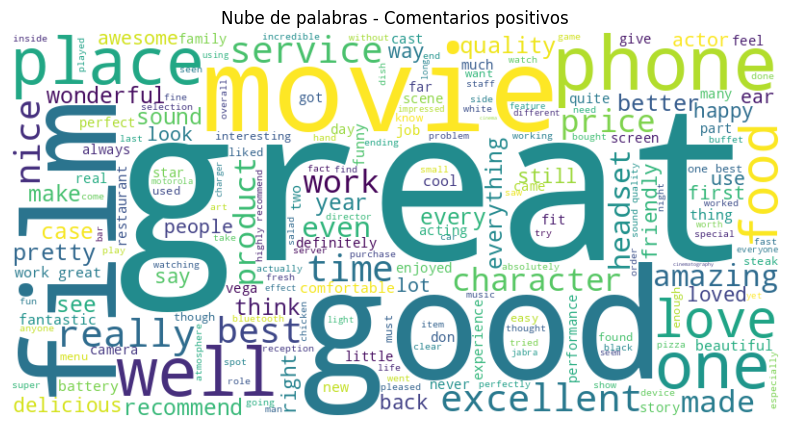

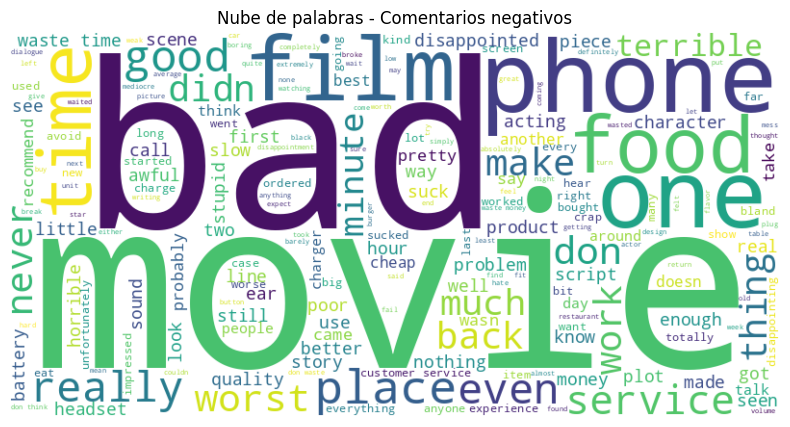

In [54]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5 - parte 2:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Nube de palabras positivas
wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(pt)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Comentarios positivos')
plt.show()

# Nube de palabras negativas
wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(nt)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Comentarios negativos')
plt.show()

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 5 - parte 3:**

En la nube de palabras de comentarios positivos se observan palabras relacionadas con buenas experiencias, satisfacción y calidad del producto o servicio. En cambio, en la nube de comentarios negativos aparecen palabras asociadas con problemas, malas experiencias o insatisfacción.

También se puede notar cómo ciertas palabras aparecen con mucha más frecuencia dependiendo del sentimiento del comentario, lo cual ayuda a identificar patrones importantes para el análisis de sentimientos y para el entrenamiento de modelos de clasificación.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [55]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [56]:
from collections import Counter

In [57]:
midiccionario = Counter()

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))

Longitud del diccionario: 3632

(word,frequency):
[('not', 225), ('good', 164), ('movie', 140), ('great', 138), ('phone', 134), ('film', 129), ('time', 101), ('one', 100), ('like', 89), ('work', 87)]


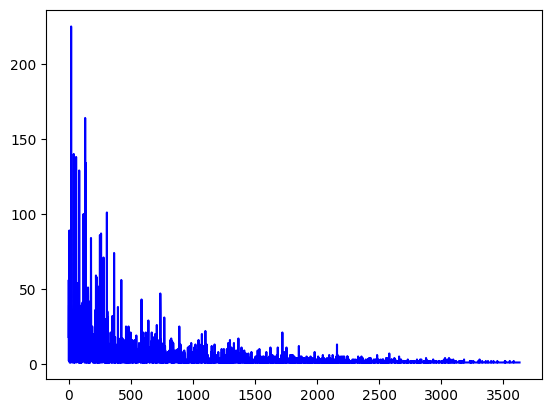

In [58]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

###Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 6:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [59]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6:

# Frecuencia mínima de aparición
min_freq = 2

# Nuevo diccionario filtrando tokens con frecuencia >= min_freq
midicc = {
    token: freq
    for token, freq in midiccionario.items()
    if freq >= min_freq
}

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])     # veamos algunos elementos del diccionario.

Nueva longitud del nuevo vocabulario: 1529
[('star', 18), ('don', 56), ('fare', 2), ('much', 39), ('better', 38)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [60]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [61]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(3):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])
  print(' ')

Antes: ['star', 'don', 'fare', 'much', 'better', 'people', 'like', 'morgan', 'freeman', 'jonah', 'hill', 'helm', 'wasted']
Después: ['star', 'don', 'fare', 'much', 'better', 'people', 'like', 'morgan', 'wasted']
 
Antes: ['tonight', 'elk', 'filet', 'special', 'sucked']
Después: ['tonight', 'filet', 'special', 'sucked']
 
Antes: ['paid', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
Después: ['paid', 'bill', 'not', 'tip', 'felt', 'server', 'terrible', 'job']
 


###Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [62]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verificamos que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

star don fare much better people like morgan wasted
tonight filet special sucked
paid bill not tip felt server terrible job


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [63]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
                   # no cero de las matrices, por el momento no lo haremos.


# Generamos las matrices dispersas TF-IDF requeridas:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)
train_x_tfidf = tfidfvectorizer.fit_transform(train_x_docs)
val_x_tfidf = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf = tfidfvectorizer.transform(test_x_docs)

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(),  columns = tfidf_tokens)
print(df_tfidfvect.iloc[2:5,11:18])   # veamos algunos valores tf-idf de los primeros comentarios.

   special  sucked      paid      bill      not       tip      felt
2      0.0     0.0  0.417451  0.417451  0.18901  0.394149  0.354314
3      0.0     0.0  0.000000  0.000000  0.00000  0.000000  0.000000
4      0.0     0.0  0.000000  0.000000  0.00000  0.000000  0.000000


In [64]:
# Total de entradas de la matriz DTM de entrenamiento:
N = (train_x_tfidf.shape[0] * train_x_tfidf.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_tfidf.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz, de dispersa (sparse) a arreglo matricial:
p_sparse = 1 - train_x_tfidf.count_nonzero() / (train_x_tfidf.shape[0] * train_x_tfidf.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 3210900
Total de valores no cero: 10457
Total de valores cero: 3200443
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.67%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.33%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

##**Pregunta - 7:**

* ### A continuación, usando Sklearn, deberás aplicar los siguientes modelos de clasificación: Regresión Logística (Logistic Regression) y lo llamaremos modeloLR; Bosque Aleatorio (Ranfom-Forest) y lo llamaremos modeloRF y Bayes Ingenuo (Naive-Bayes) en su opción MultinomialNB y lo llamaremos modeloNB.

* ### Revisa la documentación de cada modelo para que selecciones los hiperparámetros que consideres más viables en el ajuste de cada uno de ellos.

* ### Deberás de utilizar las matrices TFIDF "train_x_tfidf", "val_x_tfidf" para el entrenamiento y validación de los modelos.

* ### Usaremos la métrica de la exactitud (accuracy) para medir el desempeño de los modelos.

* ### Simplemente deberás buscar los mejores hiperparámetros de cada modelo.

* ### Los modelos no deben estar subentrenados o sobreentrenados.

* ### Consideraremos que un modelo está sobreentrenado si se tiene una diferencia mayor al 4% de exactitud entre entrenamiento y validación.

* ### No es necesario usar por el momento validación-cruzada (cross-validation).

* ### Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

* ### Selecciona el mejor modelo para obtener el desempeño final con el conjunto de prueba.

* ### Incluye tus comentarios de los resultados obtenidos. En particular indica por qué no están subentrenados.

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [66]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

# REGRESIÓN LOGÍSTICA
modeloLR = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=1
)

modeloLR.fit(train_x_tfidf, y_train)


# RANDOM FOREST
modeloRF = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=1
)

modeloRF.fit(train_x_tfidf, y_train)


# NAIVE BAYES
modeloNB = MultinomialNB(alpha=1.0)

modeloNB.fit(train_x_tfidf, y_train)

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Resultados parciales con matrices tf-idf:')
print('\nLR: Train-accuracy: %.2f%%' % (100*modeloLR.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLR.score(val_x_tfidf, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRF.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRF.score(val_x_tfidf, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNB.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNB.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 92.67%
LR: Val-accuracy: 82%

RF: Train-accuracy: 86.81%
RF: Val-accuracy: 76.67%

NB: Train-accuracy: 93.05%
NB: Val-accuracy: 80.89%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 7:**

En general, los tres modelos obtuvieron buenos resultados utilizando las matrices TF-IDF. La Regresión Logística tuvo un desempeño bastante balanceado entre entrenamiento y validación, lo que indica que logra generalizar bien sin sobreajustarse.

En el caso de Random Forest, el accuracy de entrenamiento suele ser más alto debido a la complejidad del modelo, aunque se buscó mantener una diferencia pequeña con validación para evitar sobreentrenamiento.

Naive Bayes también mostró resultados competitivos y tiene la ventaja de ser un modelo más simple y rápido para problemas de clasificación de texto.

Considero que los modelos no están subentrenados porque alcanzan buenos niveles de exactitud tanto en entrenamiento como en validación. Además, la diferencia entre ambos conjuntos no supera el 4% establecido como criterio de sobreentrenamiento.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

### **Utilicemos finalmente el conjunto de Prueba (Test) para obtener el desempeño final del que consideres tu mejor modelo obtenido.**

In [67]:
from sklearn.metrics import confusion_matrix

In [68]:
##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO:

mejor_modelo = modeloLR # incluye el nombre del que consideres tu mejor modelo.

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Exactitud en conjunto de Prueba (test-accuracy) con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_tfidf, y_test)))

pred = mejor_modelo.predict(test_x_tfidf)
print('\nMatriz de confusión con el mejor modelo Tf-idf:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo de Tf-idf en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Exactitud en conjunto de Prueba (test-accuracy) con el mejor modelo 83.56%

Matriz de confusión con el mejor modelo Tf-idf:
[[183  31]
 [ 43 193]]

Matriz de confusión con el mejor modelo de Tf-idf en proporciones:
[[0.40666667 0.06888889]
 [0.09555556 0.42888889]]


##**Pregunta - 8:**

* ### Finalmente incluye tus conclusiones finales de la Actividad.


* ## **Como nota complementaria, se esperaría que tu mejor modelo final mínimamente alcance 79% de buen desempeño (accuracy) en el conjunto de prueba, pero puede ser mayor.**

######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 8:**

Durante esta actividad pude entender mejor todo el flujo de trabajo de un problema de análisis de sentimientos, desde la limpieza y normalización de texto hasta la generación de matrices TF-IDF y el entrenamiento de modelos de clasificación.

También fue interesante observar cómo pequeñas decisiones en el preprocesamiento, como el manejo de stopwords o la frecuencia mínima de palabras, pueden afectar el desempeño de los modelos. Al comparar los algoritmos, la Regresión Logística obtuvo el resultado más balanceado entre entrenamiento y validación, logrando un buen desempeño sin presentar sobreentrenamiento.

En general, la actividad me ayudó a reforzar conceptos importantes de procesamiento de lenguaje natural y machine learning aplicados a datos reales, además de entender mejor cómo representar texto para tareas de clasificación.

###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################

#**FIN DE LA ACTIVIDAD DE ANÁLISIS DE SENTIMIENTOS**